# 过拟合及其解决方法  
过拟合 (Overfitting) 是指在机器学习中，模型过于复杂而导致在训练数据上表现良好，但在新的未见过的数据上表现不佳的现象。直观的讲，可能会在训练过程中出现模型的训练准确率约为 100％，而测试准确率仅有 80% 左右的情况。在本文中，我们直观地介绍训练与测试准确率之间的差异的原因以及解决方法。

## 1. 过拟合基本概念  
在[《神经网络性能优化技术》](../Notes/6.神经网络性能优化技术.ipynb)中，我们经常看到这样的现象——训练数据集的准确率通常超过 95%，而验证数据集的准确率大约只为 89%。从本质上讲，这表明该模型在未见过的数据上的泛化程度不高，也表明模型正在学习训练数据集的异常数据，这些情况并不适用于验证数据集。

当模型过度关注于训练数据中的细节和噪音时，会导致过拟合。过拟合通常发生在模型复杂度过高、训练数据量较少或训练数据不平衡的情况下。当模型太过复杂时，它可能在训练数据中学习到了噪声和随机性，并将其视为普遍规律。当训练数据量较少时，模型可能没有足够的样本来全面学习数据的特征分布，从而容易出现过拟合。过拟合现象使得模型对训练数据中的个别特征过于敏感，而无法正确地推广到新的数据。可以使用以下策略降低模型过拟合的影响：

- 增加训练数据的数量，确保数据集更加全面和多样化
- 减少模型的复杂度，例如减少参数数量或使用正则化方法
- 使用交叉验证等技术来评估模型的性能，并进行模型选择
- 提前停止训练，即在模型开始过拟合之前停止迭代
- 进行特征选择，删除不相关或冗余的特征
- 数据预处理，例如归一化/标准化数据，处理异常值等

## 2. 添加 Dropout 解决过拟合  
Dropout 是一种用于减少神经网络过拟合的正则化技术。在训练过程中，Dropout 会随机地将一部分神经元的输出置为 0 (即丢弃)，从而降低神经网络对特定神经元的依赖性。具体来说，在每次训练迭代中，Dropout 会以一定的概率随机选择部分神经元，并将其输出置为 0，这意味着每个神经元都有一定的概率被“关闭”，从而迫使网络学习到更加鲁棒和独立的特征表示。

![Dropout](../Images/10.1.png)

Dropout 是一种用于减少神经网络过拟合的正则化技术。在训练过程中，Dropout 会随机地将一部分神经元的输出置为 0 (即丢弃)，从而降低神经网络对特定神经元的依赖性。具体来说，在每次训练迭代中，Dropout 会以一定的概率随机选择部分神经元，并将其输出置为 0，这意味着每个神经元都有一定的概率被“关闭”，从而迫使网络学习到更加鲁棒和独立的特征表示。

正常模型训练时，每次计算 loss.backward() 时，都更新模型权重。通常，神经网络中包含数以百万计的参数，因此可能虽然大多数参数有助于训练模型，但某些参数可能会针对训练图像进行微调，从而导致它们的值仅由训练数据集中的少数图像决定，这会导致模型在训练数据上具有较高精度，但在验证数据集上的泛化能力较差。

由于 Dropout 在训练和验证过程中具有不同操作，因此必须预先指定模型的模式为 model.train() (处于训练阶段)或 model.eval() (处于验证阶段)。

定义架构时，在 get_model() 函数中指定 Dropout 如下：

In [ ]:
from torch.optim import Adam
def get_model():
    model = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(1000, 10)
    ).to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

在以上代码中，还在线性激活前添加了 Dropout，训练和验证数据集的损失和准确率变化如下所示：

![10.2](../Images/10.2.png)

使用相同的架构，未使用 Dropout 时训练和验证数据集的损失和准确率变化如下所示：

![10.3](../Images/10.3.png)

可以看出，训练数据集和验证数据集的准确率之间的差异没有之前模型差距那么大，有效的降低了模型的过拟合。

绘制两种情况下隐藏层的权重直方图，可以看到使用 Dropout 时训练和测试准确率之间的差距低于没有 Dropout 时模型训练和测试准确率的差距:  
![10.4](../Images/10.4.png)  

![10.5](../Images/10.5.png)

## 3. 使用正则化解决过拟合  
除了训练准确率远高于验证准确率外，过拟合的另一个特征是网络中的某些权重值显著高于其他权重值，高权重值可能是模型为了拟合训练数据中异常值的表现。正则化是一种惩罚模型中具有较高值的权重的技术，因此，需要同时最小化训练数据的损失以及权重值。在本节中，我们将学习两类正则化：  
- L1正则化
- L2正则化

### 3.1 L1正则化  
L1正则化计算如下：  
$$
Cross Entropy Loss = -\frac{1}{n}\Bigg(\sum_{i=1}^{n}\Big(y_i * \log(p_i) + (1-y_i) * \log(1-p_i)\Big)\Bigg)
$$

$$
L2\ loss = -\frac{1}{n}\left(\sum_{i=1}^{n}\left(y_i * \log(p_i) + (1 - y_i) * \log(1 - p_i)\right) + \Lambda \sum_{j=1}^{m} w_j^2\right)
$$

其中，第一部分是指分类交叉熵损失，而第二部分是指模型权重值的平方和，\Lambda 是用于平衡交叉熵损失和权重平方和的权重系数。与 L1 正则化类似，通过将权重的平方和纳入损失计算来惩罚较高权重值。L2 正则化同样在训练模型的同时进行：

In [2]:
def train_batch(x, y, model, opt, loss_fn):
    prediction = model(x)
    l2_regularization = 0
    for param in model.parameters():
        l2_regularization += param.norm(2)
    batch_loss = loss_fn(prediction, y) + 1e-2 * l2_regularization
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

在以上代码中，正则化的权重参数 (0.01) 略高于 L1 正则化，因为权重通常在 -1 到 1 之间，并且执行平方后会得到更小的结果值，如果权重参数较小，将导致在整体损失计算第二项的影响非常小。

使用 L2 正则化后，训练和验证数据集上的损失和准确率的变化情况如下所示：

![10.6](../Images/10.6.png)

可以看到 L2 正则化同样可以令验证和训练数据集的准确率和损失更接近。

最后，我们比较没有进行正则化和使用 L1/L2 正则化的权重，观察网络层的权重分布，如下图所示：

![10.7](../Images/10.7.png)

可以看到，与不执行正则化相比，执行 L1/L2 正则化时参数的分布范围非常小，这可能会减少为异常数据更新权重的机会。  

我们已经知道了[较高的学习率在缩放和未缩放的数据集上均难以得到最佳结果](./9.学习率优化.ipynb)，在下一节中，我们将学习如何在模型开始过拟合时自动降低学习率.

## 4. 学习率衰减  
在以上模型中，我们在模型训练过程中使用恒定的学习率，但是，通常可以将权重快速更新到接近最佳状态，在模型训练后期可以进行缓慢的更新，因为模型训练初期的损失较高，而在后期损失较低。这就需要模型训练初期具有较高学习率，然后随着模型接近最佳的准确率，学习率也需要逐渐降低，因此我们这需要了解在何时降低学习率。

一种常用的方法是持续监控验证损失，如果验证损失在一段 epoch 内没有减少，就降低学习率。PyTorch 提供了调度方法 lr_scheduler，当验证损失在之前的 “x” 个 epoch 内没有减少时，降低学习率：

In [ ]:
from torch import optim
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                factor=0.5,patience=0,
                                                threshold=0.001
                                                verbose=True,
                                                min_lr=1e-5
                                                threshold_mode='abs')

在以上代码中，指定如果某个值在接下来的 n 个 epoch (使用 patience参数指定)没有提高指定阈值(使用 threshold 参数指定)，则学习率衰减为原来的 0.5 倍(即变为原来的 1/2，使用 factor 参数指定)，且使用参数 min_lr 指定学习率的最小值 (不低于 1e-5)，并且使用参数 threshold_mode 指定阈值模式(此处使用 abs，以确保超过指定的最小阈值)。接下来，在训练模型时应用 lr_scheduler，并在模型训练时监测验证损失：

Using device: cpu
Epoch    2: reducing learning rate of group 0 to 5.0000e-02.
Epoch    3: reducing learning rate of group 0 to 2.5000e-02.
Epoch    7: reducing learning rate of group 0 to 1.2500e-02.
Epoch   12: reducing learning rate of group 0 to 6.2500e-03.
Epoch   15: reducing learning rate of group 0 to 3.1250e-03.
Epoch   20: reducing learning rate of group 0 to 1.5625e-03.
Epoch   22: reducing learning rate of group 0 to 7.8125e-04.
Epoch   24: reducing learning rate of group 0 to 3.9063e-04.
Epoch   26: reducing learning rate of group 0 to 1.9531e-04.
Epoch   28: reducing learning rate of group 0 to 9.7656e-05.
Epoch   29: reducing learning rate of group 0 to 4.8828e-05.
Epoch   30: reducing learning rate of group 0 to 2.4414e-05.


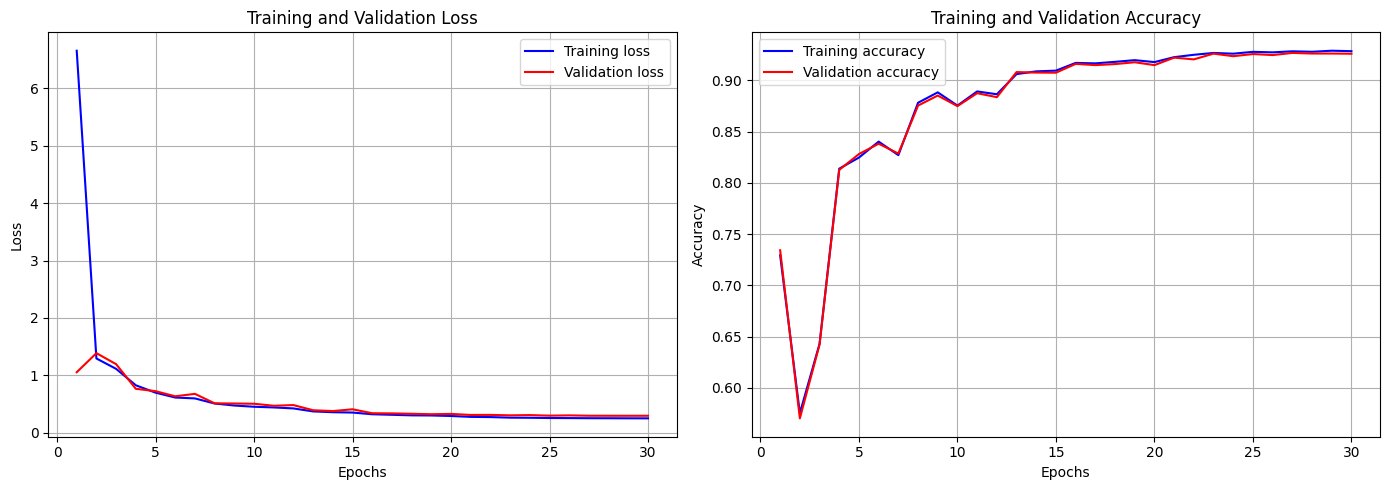

In [17]:
import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 强制使用CPU
device = torch.device("cpu")
print(f"Using device: {device}")

# 1. 获取数据的函数
def get_data(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    val_dataset = datasets.MNIST('./data', train=False, transform=transform)
    
    trn_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return trn_dl, val_dl

# 2. 获取模型的函数
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-1)
    return model, loss_fn, optimizer

# 训练一个batch的函数
def train_batch(x, y, model, optimizer, loss_fn):
    x = x.view(x.size(0), -1).to(device)
    y = y.to(device)
    
    optimizer.zero_grad()
    output = model(x)
    loss = loss_fn(output, y)
    loss.backward()
    optimizer.step()
    
    return loss.item()

# 计算准确率的函数
def accuracy(x, y, model):
    x = x.view(x.size(0), -1).to(device)
    y = y.to(device)
    
    with torch.no_grad():
        output = model(x)
        pred = output.argmax(dim=1)
        is_correct = (pred == y).cpu().numpy()
    
    return is_correct

# 计算验证损失的函数
def validation_loss(x, y, model, loss_fn):
    x = x.view(x.size(0), -1).to(device)
    y = y.to(device)
    
    with torch.no_grad():
        output = model(x)
        loss = loss_fn(output, y)
    
    return loss.item()

# 主训练代码
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

# 记录上一次的学习率，用于检测变化
last_lr = optimizer.param_groups[0]['lr']

# 3. 创建学习率调度器 - 注意这里设置verbose=False，我们会自己打印
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=0.5,
    patience=0,  # patience=0表示如果验证损失没有立即改善就降低学习率
    threshold=0.001,
    verbose=False,  # 设置为False，我们自己控制打印格式
    min_lr=1e-5,
    threshold_mode='abs'
)

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

# 训练循环
for epoch in range(30):
    # 训练阶段
    model.train()
    train_epoch_losses, train_epoch_accuracies = [], []
    
    # 计算训练损失
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    
    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_losses.append(train_epoch_loss)
    
    # 计算训练准确率
    train_epoch_accuracies = []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    train_accuracies.append(train_epoch_accuracy)
    
    # 验证阶段
    model.eval()
    val_epoch_losses, val_epoch_accuracies = [], []
    
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        
        # 验证损失
        val_loss = validation_loss(x, y, model, loss_fn)
        val_epoch_losses.append(val_loss)
        
        # 验证准确率
        is_correct = accuracy(x, y, model)
        val_epoch_accuracies.extend(is_correct)
    
    validation_loss_mean = np.mean(val_epoch_losses)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    
    # 记录验证指标
    val_losses.append(validation_loss_mean)
    val_accuracies.append(val_epoch_accuracy)
    
    # 获取当前学习率
    current_lr = optimizer.param_groups[0]['lr']
    
    # 更新学习率调度器（基于验证损失）- 先调用step再检查变化
    scheduler.step(validation_loss_mean)
    
    # 检查学习率是否变化，如果变化则打印信息
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != last_lr:
        print(f"Epoch {epoch+1:4d}: reducing learning rate of group 0 to {new_lr:.4e}.")
        last_lr = new_lr
    
# 绘制训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
ax1.plot(range(1, 31), train_losses, 'b-', label='Training loss')
ax1.plot(range(1, 31), val_losses, 'r-', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# 准确率曲线
ax2.plot(range(1, 31), train_accuracies, 'b-', label='Training accuracy')
ax2.plot(range(1, 31), val_accuracies, 'r-', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

在以上代码中，指定只要验证损失在连续的 epoch 内没有减少，就激活调度程序，学习率降低 0.5 倍，模型上执行调度程序输出如上

训练和验证数据集的准确率和损失随时间变化如上

通过使用调度程序，即使对模型进行了 30 个(或更多) epoch 的训练，也没有严重的过拟合问题，这是因为当学习率衰减的极小时，权重的更新也变得非常小，因此训练和验证准确率之间的差距也非常小。

## 小结  
过拟合是指机器学习模型在训练集上表现很好，但在测试集或未见过的数据上表现较差的现象。过拟合是由于模型在训练过程中过度拟合了训练数据的特点和噪声，导致了对训练样本的过度依赖和泛化能力不足。为了解决过拟合问题，选择适当的方法需要对具体问题和数据进行分析，并在模型构建和调优过程中进行实验和验证。在实践中，通常需要权衡模型的复杂度和泛化能力，以获得更好的结果。​
​
​